In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm
import pickle

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

import warnings
warnings.filterwarnings("ignore")

In [2]:
ds_train = pd.read_csv('./data/chunks_specie_sample_train.csv')
ds_test = pd.read_csv('./data/chunks_specie_sample_test.csv')
ds_val = pd.read_csv('./data/chunks_specie_sample_val.csv')
ds_train = ds_train[['audio_path', 'label']]
ds_test = ds_test[['audio_path', 'label']]
ds_val = ds_val[['audio_path', 'label']]
print(ds_train.shape)
print(ds_test.shape)
print(ds_val.shape)
ds_train.sample(5)

(12730, 2)
(2674, 2)
(6292, 2)


,audio_path,label
365,chunks/701133_chunk4.mp3,Troglodytes aedon
10390,chunks/253319_chunk13.mp3,Troglodytes aedon
1184,chunks/690582_chunk6.mp3,Troglodytes aedon
3193,chunks/127867_chunk5.mp3,Troglodytes aedon
2322,chunks/590623_chunk27.mp3,Troglodytes aedon


In [3]:
ds_val = ds_val[ds_val['audio_path'] != 'chunks/90580_chunk1.mp3']
ds_val.reset_index(drop=True, inplace=True)

# guardar los datasets
#ds_val.to_csv('./data/chunks_specie_sample_train.csv', index=False)

In [4]:
# label encoder
le = LabelEncoder()
ds_train['label'] = le.fit_transform(ds_train['label'])
ds_test['label'] = le.transform(ds_test['label'])
ds_val['label'] = le.transform(ds_val['label'])

In [5]:
etiquetas = ds_train['label']
clases, conteo_clases = np.unique(etiquetas, return_counts=True)
weight = dict(zip(clases, np.max(conteo_clases) / conteo_clases))

In [6]:
X = ds_train['audio_path']
y = ds_train['label']

X_test = ds_test['audio_path']
y_test = ds_test['label']

X_val = ds_val['audio_path']
y_val = ds_val['label']

In [7]:
num_clases = y.nunique()
print(num_clases)

9


In [8]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.
    
    Parameters:
    path (str): The file path to the audio file.
    
    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path, sr=None, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=10000)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [9]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.
    
    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.
        
    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []
    
    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])
        
    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)
    
    return X_processed, y_processed

In [ ]:
#%%time
X_processed, y = process_audio_files(X, y)
X_test_processed, y_test = process_audio_files(X_test, y_test)
X_val_processed, y_val = process_audio_files(X_val, y_val)

In [21]:
with open('X_processed.pkl', 'wb') as f:
    pickle.dump(X_processed, f)
    
with open('y_train.pkl', 'wb') as f:
    pickle.dump(y, f)

with open('X_test_processed.pkl', 'wb') as f:
    pickle.dump(X_test_processed, f)
    
with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)
    
with open('X_val_processed.pkl', 'wb') as f:
    pickle.dump(X_val_processed, f)
    
with open('y_val.pkl', 'wb') as f:
    pickle.dump(y_val, f)

In [10]:
with open('X_processed.pkl', 'rb') as f:
    X_processed = pickle.load(f)

with open('y_train.pkl', 'rb') as f:
    y = pickle.load(f)

with open('X_test_processed.pkl', 'rb') as f:
    X_test_processed = pickle.load(f)
    
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('X_val_processed.pkl', 'rb') as f:
    X_val_processed = pickle.load(f)
    
with open('y_val.pkl', 'rb') as f:
    y_val = pickle.load(f)

In [11]:
print(f'El conjunto de entrenamiento tiene la forma {X_processed.shape}')
print(f'Los labels del conjunto de entrenamiento tiene la forma {y.shape}')

El conjunto de entrenamiento tiene la forma (12730, 65, 40)
Los labels del conjunto de entrenamiento tiene la forma (12730,)


## **Modelo**

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

In [13]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [14]:
print(tf.config.list_physical_devices('GPU'))

[]


In [15]:
# Add attention layer to the deep learning network
class Attention(layers.Layer):
    """
    Custom Keras Layer implementing an Attention mechanism.
    
    Methods
    -------
    build(input_shape)
        Initializes the weights and biases for the attention mechanism.
    
    call(x)
        Applies the attention mechanism to the input tensor `x` and returns the context vector.
        
    Parameters
    ----------
    input_shape : tuple
        Shape of the input tensor.
        
    x : tensor
        Input tensor to which the attention mechanism is applied.
        
    Returns
    -------
    tensor
        Context vector obtained after applying the attention mechanism.
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), 
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), 
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
        
    def call(self, x):
        # Alignment scores. Pass them through tanh function
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # Cambiado K.dot por tf.matmul
        # Remove dimension of size 1
        e = tf.squeeze(e, axis=-1)  # Cambiado K.squeeze por tf.squeeze
        # Compute the weights
        alpha = tf.nn.softmax(e)  # Cambiado K.softmax por tf.nn.softmax
        # Reshape to tensorFlow format
        alpha = tf.expand_dims(alpha, axis=-1)  # Cambiado K.expand_dims por tf.expand_dims
        # Compute the context vector
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)  # Cambiado K.sum por tf.reduce_sum
        return context

In [16]:
del Attention

In [18]:
from tensorflow.keras.layers import Attention

# Capa de entrada
input_layer = layers.Input(shape=(65, 40), name='input_layer')

# Bloque convolucional 1
x = layers.Conv1D(filters=64, kernel_size=6, padding='same')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 2
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 3
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=15, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Capas LSTM bidireccionales
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
x = layers.Dropout(0.5)(x)

# Capa de atención
x = Attention()([x, x])

# Capas densas
x = layers.Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)

# Capa de salida
output_layer = layers.Dense(num_clases, activation='softmax', name='output_layer')(x)

# Creación del modelo
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 65, 40)]     0           []                               
                                                                                                  
 conv1d_6 (Conv1D)              (None, 65, 64)       15424       ['input_layer[0][0]']            
                                                                                                  
 batch_normalization_6 (BatchNo  (None, 65, 64)      256         ['conv1d_6[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_6 (Activation)      (None, 65, 64)       0           ['batch_normalization_6[0][

In [19]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.keras',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=False,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=15, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [20]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(adam, ls, metrics=['accuracy'])

history = model.fit(X_processed, y, 
                    validation_data=(X_val_processed, y_val),
                    callbacks=callbacks,
                    epochs=1000,
                    batch_size=32,
                    class_weight=weight)

Epoch 1/1000
398/398 [==============================] - ETA: 0s - loss: 12.9750 - accuracy: 0.0601
Epoch 1: val_loss improved from inf to 2.38179, saving model to model_weights_mfcc.keras
398/398 [==============================] - 72s 159ms/step - loss: 12.9750 - accuracy: 0.0601 - val_loss: 2.3818 - val_accuracy: 0.0072 - lr: 0.0100
Epoch 2/1000
398/398 [==============================] - ETA: 0s - loss: 11.9766 - accuracy: 0.0263
Epoch 2: val_loss improved from 2.38179 to 2.23289, saving model to model_weights_mfcc.keras
398/398 [==============================] - 61s 152ms/step - loss: 11.9766 - accuracy: 0.0263 - val_loss: 2.2329 - val_accuracy: 0.0105 - lr: 0.0100
Epoch 3/1000
398/398 [==============================] - ETA: 0s - loss: 11.9289 - accuracy: 0.0736
Epoch 3: val_loss improved from 2.23289 to 2.23030, saving model to model_weights_mfcc.keras
398/398 [==============================] - 61s 153ms/step - loss: 11.9289 - accuracy: 0.0736 - val_loss: 2.2303 - val_accuracy: 0.02

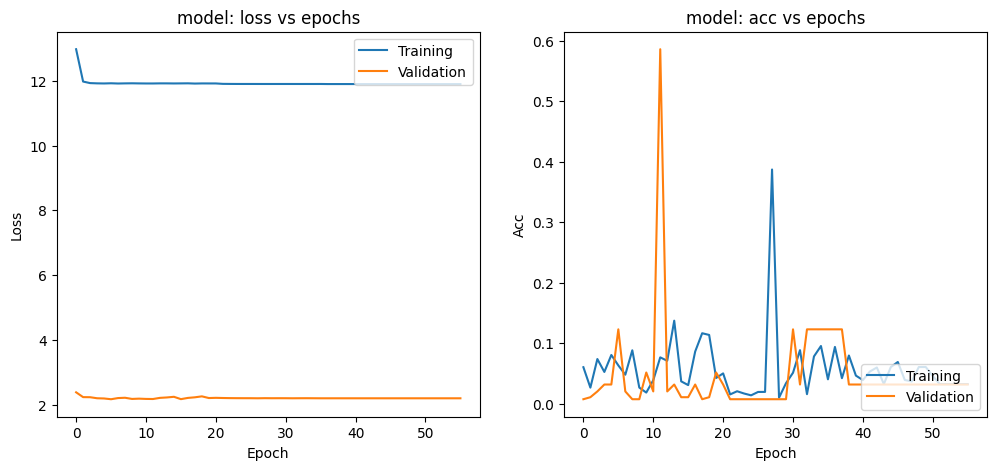

In [22]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## **Predicción**

In [23]:
#carga el modelo model_weights_mfcc
model = tf.keras.models.load_model('model_weights_mfcc.keras', custom_objects={'Attention': Attention})

In [24]:
preds = model.predict(X_test_processed)
model.evaluate(X_test_processed, y_test)

84/84 [==============================] - 5s 30ms/step - loss: 2.1740 - accuracy: 0.0770


[2.1740152835845947, 0.07703814655542374]

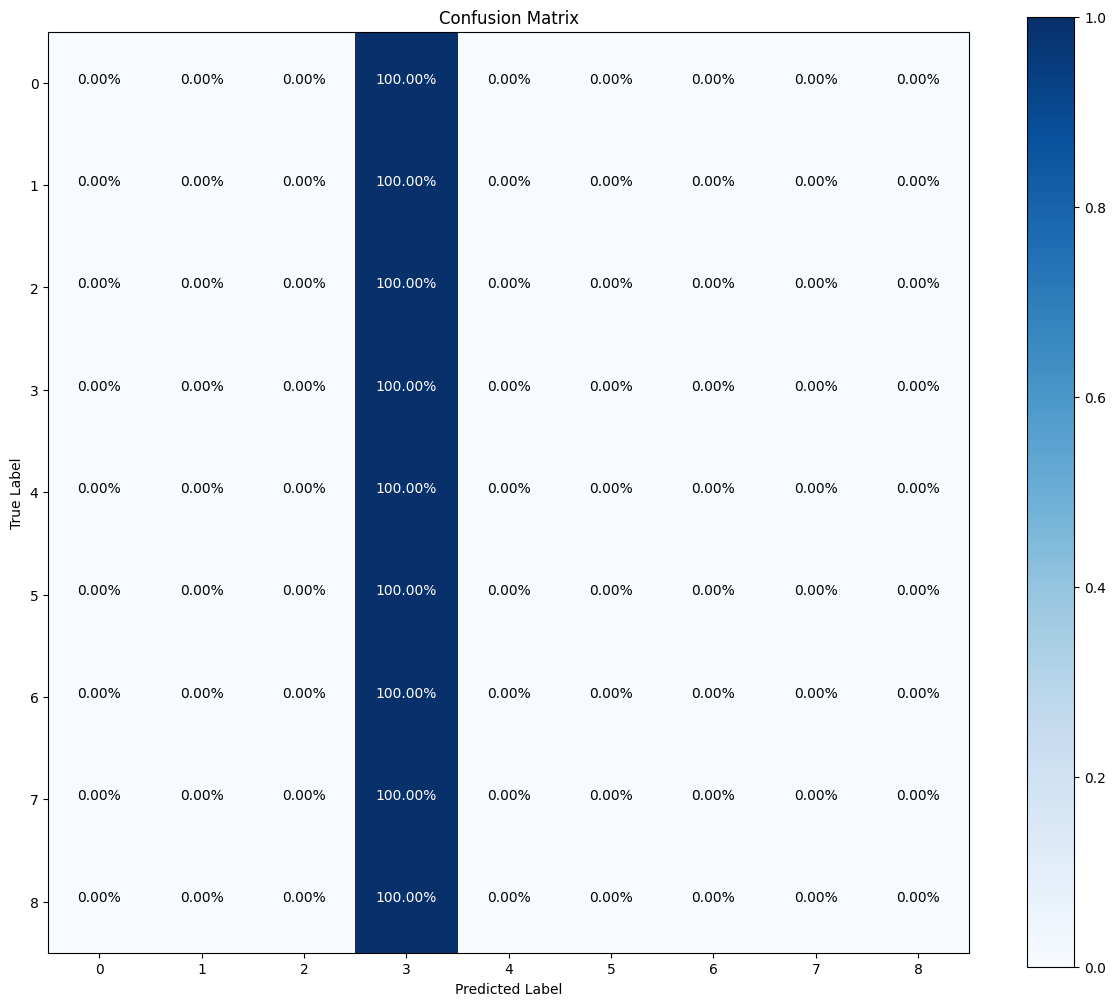

In [29]:
cm = confusion_matrix(y_test, np.argmax(preds, axis=1))

# Número de clases
num_classes = cm.shape[0]

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Graficar
plt.figure(figsize=(12, 10))  # Opcional, para ajustar el tamaño de la figura
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=0)
plt.yticks(tick_marks, range(num_classes))

# Anotar la matriz
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2%}",
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Guardar la figura en formato PDF
plt.savefig('confusion_matrix.pdf', format='pdf')
plt.show()

In [26]:
accuracy_score(y_test, np.argmax(preds, axis=1))

0.07703814510097233

In [27]:
#codificar las etiquetas
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(np.argmax(preds, axis=1))

In [28]:
print(classification_report(y_test_labels, y_pred_labels))

                              precision    recall  f1-score   support

Campylorhynchus albobrunneus       0.00      0.00      0.00        29
     Campylorhynchus zonatus       0.00      0.00      0.00        87
       Cistothorus apolinari       0.00      0.00      0.00       114
       Cistothorus platensis       0.08      1.00      0.14       206
        Microcerculus bambla       0.00      0.00      0.00        82
    Microcerculus marginatus       0.00      0.00      0.00       557
     Odontorchilus branickii       0.00      0.00      0.00        18
           Troglodytes aedon       0.00      0.00      0.00      1507
    Troglodytes solstitialis       0.00      0.00      0.00        74

                    accuracy                           0.08      2674
                   macro avg       0.01      0.11      0.02      2674
                weighted avg       0.01      0.08      0.01      2674

